In [23]:
import numpy as np
import pandas as pd

In [24]:
print(pd.date_range("2026-01-01", periods=4, freq="ME"))

DatetimeIndex(['2026-01-31', '2026-02-28', '2026-03-31', '2026-04-30'], dtype='datetime64[ns]', freq='ME')


In [25]:
print(pd.date_range("2026-01-01", periods=4, freq="MS"))

DatetimeIndex(['2026-01-01', '2026-02-01', '2026-03-01', '2026-04-01'], dtype='datetime64[ns]', freq='MS')


In [26]:
print(pd.date_range("2026-01-01", periods=4, freq="QE"))

DatetimeIndex(['2026-03-31', '2026-06-30', '2026-09-30', '2026-12-31'], dtype='datetime64[ns]', freq='QE-DEC')


In [27]:
print(pd.date_range("2026-01-01", periods=4, freq="QS"))

DatetimeIndex(['2026-01-01', '2026-04-01', '2026-07-01', '2026-10-01'], dtype='datetime64[ns]', freq='QS-JAN')


In [28]:
print(pd.date_range("2026-01-01", periods=4, freq="W"))

DatetimeIndex(['2026-01-04', '2026-01-11', '2026-01-18', '2026-01-25'], dtype='datetime64[ns]', freq='W-SUN')


In [29]:
print(pd.date_range("2026-01-01", periods=4, freq="W"))

DatetimeIndex(['2026-01-04', '2026-01-11', '2026-01-18', '2026-01-25'], dtype='datetime64[ns]', freq='W-SUN')


In [30]:
print(pd.date_range("2026-01-01", periods=4, freq="4W-MON"))

DatetimeIndex(['2026-01-05', '2026-02-02', '2026-03-02', '2026-03-30'], dtype='datetime64[ns]', freq='4W-MON')


In [31]:
ind = pd.read_csv("D:/Obsidian/base/-Python/Python libraries/assets/index.csv", sep=";", parse_dates=["Date"])
print(ind.head())
print(ind.dtypes)

        Date    Open    High     Low   Close  Adj Close    Volume
0 2026-03-11  105.14  114.08  104.49  109.34     109.34  24466129
1 2026-03-10   95.14   98.40   95.00   96.43      96.43   7052100
2 2026-03-09   87.36   95.20   86.50   94.94      94.94   9983800
3 2026-03-06   92.30   94.95   88.80   89.33      89.33   7829400
4 2026-03-05   96.75   99.25   91.62   95.65      95.65   8769300
Date         datetime64[ns]
Open                float64
High                float64
Low                 float64
Close               float64
Adj Close           float64
Volume                int64
dtype: object


In [32]:
index = pd.DatetimeIndex(ind["Date"])
ind.index = index
ind = ind["Close"]
print(ind.head()) 

Date
2026-03-11    109.34
2026-03-10     96.43
2026-03-09     94.94
2026-03-06     89.33
2026-03-05     95.65
Name: Close, dtype: float64


In [33]:
import matplotlib.pyplot as plt

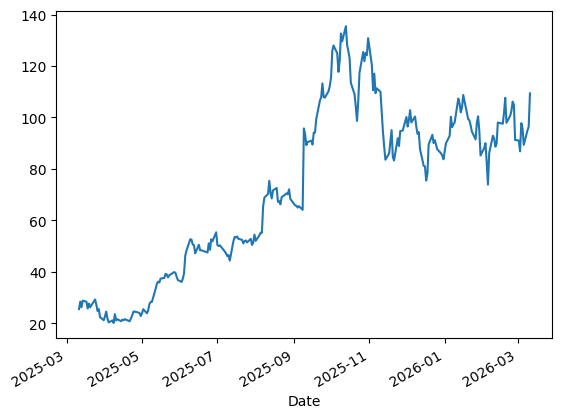

In [34]:
ind.plot()
plt.show()

In [35]:
df = pd.read_csv("D:/Obsidian/base/-Python/Python libraries/assets/FremontBridge.csv",
                index_col = "Date",
                parse_dates=True,
                date_format= '%m/%d/%Y %I:%M:%S %p')
print(df.head())
print(df.dtypes)

                     Fremont Bridge Total  Fremont Bridge East Sidewalk  \
Date                                                                      
2019-11-01 00:00:00                  12.0                           7.0   
2019-11-01 01:00:00                   7.0                           0.0   
2019-11-01 02:00:00                   1.0                           0.0   
2019-11-01 03:00:00                   6.0                           6.0   
2019-11-01 04:00:00                   6.0                           5.0   

                     Fremont Bridge West Sidewalk  
Date                                               
2019-11-01 00:00:00                           5.0  
2019-11-01 01:00:00                           7.0  
2019-11-01 02:00:00                           1.0  
2019-11-01 03:00:00                           0.0  
2019-11-01 04:00:00                           1.0  
Fremont Bridge Total            float64
Fremont Bridge East Sidewalk    float64
Fremont Bridge West Sidewalk  

In [36]:
print(df.columns)
df.columns = ["Total", "East", "West"]
print(df.head())

Index(['Fremont Bridge Total', 'Fremont Bridge East Sidewalk',
       'Fremont Bridge West Sidewalk'],
      dtype='object')
                     Total  East  West
Date                                  
2019-11-01 00:00:00   12.0   7.0   5.0
2019-11-01 01:00:00    7.0   0.0   7.0
2019-11-01 02:00:00    1.0   0.0   1.0
2019-11-01 03:00:00    6.0   6.0   0.0
2019-11-01 04:00:00    6.0   5.0   1.0


In [37]:
print(df.describe())
print(df.dropna().describe())

               Total           East           West
count  147256.000000  147256.000000  147255.000000
mean      110.340794      50.077504      60.263699
std       140.421808      64.633895      87.252147
min         0.000000       0.000000       0.000000
25%        14.000000       6.000000       7.000000
50%        60.000000      28.000000      30.000000
75%       145.000000      68.000000      74.000000
max      1097.000000     698.000000     850.000000
               Total           East           West
count  147255.000000  147255.000000  147255.000000
mean      110.341462      50.077763      60.263699
std       140.422051      64.634038      87.252147
min         0.000000       0.000000       0.000000
25%        14.000000       6.000000       7.000000
50%        60.000000      28.000000      30.000000
75%       145.000000      68.000000      74.000000
max      1097.000000     698.000000     850.000000


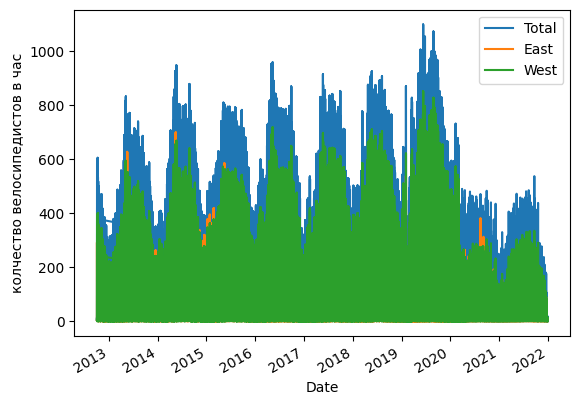

In [38]:
import matplotlib.pyplot as plt
df.plot()
plt.ylabel("колчество велосипедистов в час")
plt.show()

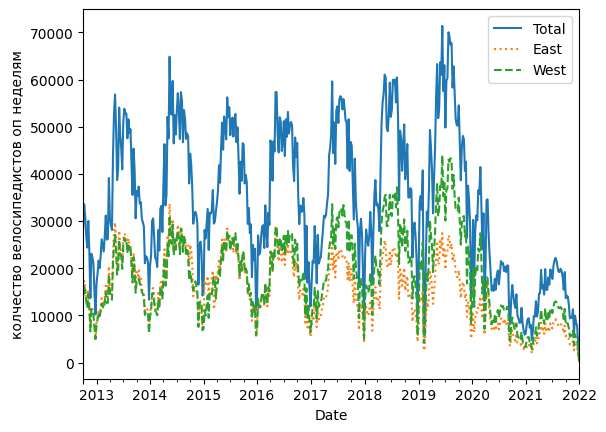

In [39]:
weekly = df.resample("W").sum()
weekly.plot(style=["-", ":", "--"])
plt.ylabel("колчество велосипедистов оп неделям")
plt.show()

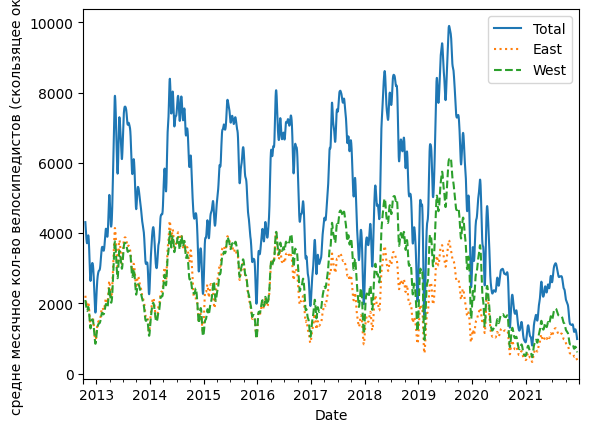

In [40]:
daily = df.resample("D").sum()
daily.rolling(30, center=True, win_type="gaussian").mean(std = 5).plot(style=["-", ":", "--"])
plt.ylabel("средне месячное кол-во велосипедистов (скользяцее окно)")
plt.show()

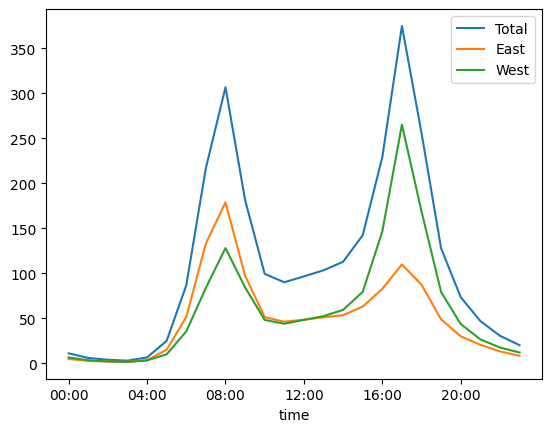

In [41]:
timely = df.groupby(df.index.time).mean()
ticks = 60*60*4* np.arange(6)
timely.plot(xticks = ticks)
plt.show()

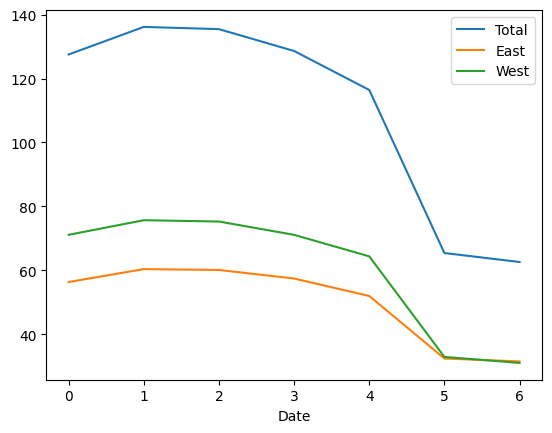

In [42]:
weekly = df.groupby(df.index.dayofweek).mean()
weekly.plot()
plt.show()

In [43]:
w1 = np.where(df.index.weekday < 5, "Будни", "Выходные")
print(w1.shape)
t1 = df.groupby([w1, df.index.time]).mean()

(147278,)


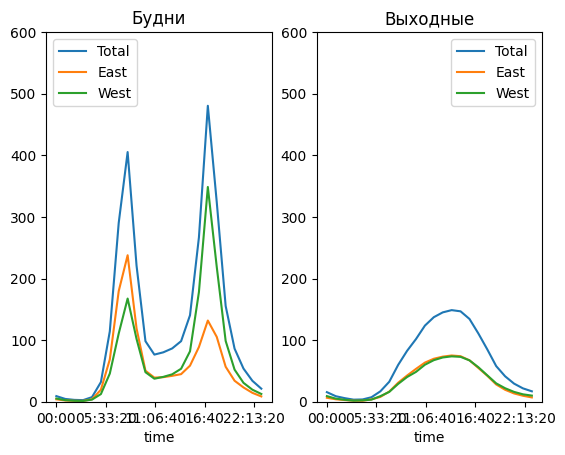

In [44]:
fig, ax = plt.subplots(1, 2)
ax[0].set_ylim(0, 600)
ax[1].set_ylim(0, 600)
t1.loc["Будни"].plot(ax=ax[0], title="Будни")
t1.loc["Выходные"].plot(ax=ax[1], title="Выходные")
plt.show()

In [45]:
plt.style.use('classic')

In [46]:
plt.show()

In [47]:
fig.savefig("fig.png")

In [48]:
print(fig.canvas.get_supported_filetypes())

{'eps': 'Encapsulated Postscript', 'jpg': 'Joint Photographic Experts Group', 'jpeg': 'Joint Photographic Experts Group', 'pdf': 'Portable Document Format', 'pgf': 'PGF code for LaTeX', 'png': 'Portable Network Graphics', 'ps': 'Postscript', 'raw': 'Raw RGBA bitmap', 'rgba': 'Raw RGBA bitmap', 'svg': 'Scalable Vector Graphics', 'svgz': 'Scalable Vector Graphics', 'tif': 'Tagged Image File Format', 'tiff': 'Tagged Image File Format', 'webp': 'WebP Image Format'}
